# LQR Solver — Optimal Execution & Markowitz Portfolio

`lqr_solver.py` is the only external file needed. It accepts raw matrices `(A, B, Q, R, M, s0)` and works for any finite-horizon LQR problem via backward induction.

CVXPY, an open source Python-embedded modeling language for convex optimization problems, is used as a verification tool to confirm the LQR solution is correct.

| Section | Problem | State |
|:---|:---|:---|
| A | Optimal Execution (single asset) | 3-D augmented `[w, alpha, c]` |
| B | Multi-Asset Markowitz Portfolio | (n+1)-D augmented `[w, 1]` |

---
## 0  Imports

In [1]:
import sys, os
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import time

# Make the parent (lqr/) and the current notebooks/ folder importable
NOTEBOOK_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(NOTEBOOK_DIR)
for _p in (PARENT_DIR, NOTEBOOK_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from lqr import solve_and_execute_lqr

from build_matrix import (
    build_execution_matrices,
    build_markowitz_matrices,
    build_given_weight_single_matrices,
    build_given_weight_multi_matrices,
    build_risk_parity_matrices,
)
from visual import (
    setup_dark_style,
    style_ax,
    COLORS,
    ASSET_PALETTE,
    plot_single_asset_results,
    plot_multi_asset_results,
)

print("Import successful!")

setup_dark_style()
os.makedirs('result', exist_ok=True)
print('Ready.')

Import successful!
Ready.


---
# Part A — Optimal Execution

## Problem Overview

At each step the agent holds a position $w_t$, observes a decaying alpha signal $\alpha_t$,
and chooses a trade $u_t$ to balance three competing forces:

| Force | Intuition | Cost term |
|:---|:---|:---|
| **Alpha capture** | Trade in the signal direction while it lasts | $-\alpha_t u_t$ (reward) |
| **Risk** | Large positions expose us to volatility | $\frac{1}{2}\gamma\sigma^2 w_{t+1}^2$ |
| **Execution impact** | Past trades leave lingering market impact | $u^\top Q_{\text{ow}}\, u$ |

---
## State, Control & Dynamics

$$s_t = \begin{bmatrix} w_t \\ \alpha_t \\ c_t \end{bmatrix} \qquad u_t = \delta w_t$$

| Symbol | Meaning |
|:---|:---|
| $w_t$ | Current position |
| $\alpha_t$ | Predictive signal — decays as $\alpha_{t+1} = \rho\,\alpha_t$ |
| $c_t$ | Accumulated impact from past trades — decays as $c_{t+1} = \beta c_t + \beta\eta u_t$ |
| $u_t$ | Trade size (control action) |

The full transition $s_{t+1} = A s_t + B u_t$ is:

$$\begin{bmatrix} w_{t+1} \\ \alpha_{t+1} \\ c_{t+1} \end{bmatrix}
=
\underbrace{\begin{bmatrix} 1 & 0 & 0 \\ 0 & \rho & 0 \\ 0 & 0 & \beta \end{bmatrix}}_{A}
\begin{bmatrix} w_t \\ \alpha_t \\ c_t \end{bmatrix}
+
\underbrace{\begin{bmatrix} 1 \\ 0 \\ \beta\eta \end{bmatrix}}_{B} u_t$$

> **Key insight:** Expanding the $c$ recursion over all steps gives $\sum_t c_t u_t = u^\top Q_{\text{ow}}^{\text{off-diag}} u$.
> Combined with the $R$ diagonal, the LQR solves the **exact same objective** as a direct CVXPY formulation — no approximation.

---
## LQR Cost Matrices

Per-step cost: $\;s_t^\top Q\, s_t \;+\; u_t^\top R\, u_t \;+\; 2\,s_t^\top M\, u_t$ = $\begin{bmatrix} s_t \\ u_t \end{bmatrix}^\top \underbrace{\begin{bmatrix} Q & M \\ M^\top & R \end{bmatrix}}_{H} \begin{bmatrix} s_t \\ u_t \end{bmatrix}$

| Matrix | Shape | Value | What it encodes |
|:---|:---|:---|:---|
| $Q$ | $(3,3)$ | `diag([0.5γσ², 0, 0])` | Risk penalty on holding position $w_t$ |
| $R$ | $(1,1)$ | `[[0.5γσ² + 0.5η]]` | Risk + execution cost on trade $u_t$ |
| $M$ | $(3,1)$ | `[[0.5γσ²], [-0.5], [0.5]]` | Links: risk cross-term, alpha reward, impact kernel |
| $s_0$ | $(3,)$ | `[0, α₀, 0]` | Start flat, with initial signal, zero impact |

**H must be positive semi-definite** for the problem to be convex and well-posed.

---


## A1  Parameters & Matrices

In [2]:
# ════════════════════════════════════════════════════════
#  Edit parameters here
# ════════════════════════════════════════════════════════
T_ex        = 30
gamma_ex    = 1.0
sigma_sq_ex = 0.04
eta_ex      = 0.1
rho_ex      = 0.95
beta_ex     = 0.8
alpha0_ex   = 1.0
# ════════════════════════════════════════════════════════

A_ex, B_ex, Q_ex, R_ex, M_ex, s0_ex = build_execution_matrices(
    gamma=gamma_ex, sigma_sq=sigma_sq_ex, eta=eta_ex,
    rho=rho_ex, beta=beta_ex, alpha0=alpha0_ex,
)

print(f'T={T_ex}, gamma={gamma_ex}, sigma_sq={sigma_sq_ex}, eta={eta_ex}, rho={rho_ex}, beta={beta_ex}, alpha0={alpha0_ex}')

T=30, gamma=1.0, sigma_sq=0.04, eta=0.1, rho=0.95, beta=0.8, alpha0=1.0


## A2  Solve (LQR) + Verify (CVXPY)

In [3]:
# ── LQR — median timing over N_REPEAT runs ───────────────
N_REPEAT = 100

times_lqr = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    result_ex = solve_and_execute_lqr(T_ex, A_ex, B_ex, Q_ex, R_ex, M_ex, s0_ex)
    times_lqr.append((time.perf_counter() - t0) * 1000)

time_lqr_ex = np.median(times_lqr)
# Extract trajectories from result
s_lqr_ex = result_ex.s_path
u_lqr_ex = result_ex.u_path
w_lqr_ex = s_lqr_ex[1:, 0]
u_lqr_ex_w = u_lqr_ex[:, 0]

# ── CVXPY — median timing over N_REPEAT runs ─────────────
# Identical objective to LQR:
#   -alphas'u  +  0.5*gamma*sigma_sq*sum(w_t^2)  +  u'*Q_ow*u
alphas_ex = alpha0_ex * (rho_ex ** np.arange(T_ex))
i_idx, j_idx = np.indices((T_ex, T_ex))
Q_ow = (eta_ex / 2.0) * (beta_ex ** np.abs(i_idx - j_idx))

times_cvx = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    u_v = cp.Variable(T_ex)
    w_v = cp.Variable(T_ex)
    con_ex = [w_v[0] == u_v[0]]
    for t in range(1, T_ex):
        con_ex.append(w_v[t] == w_v[t-1] + u_v[t])
    cost_ex = (-alphas_ex @ u_v
               + 0.5*gamma_ex*sigma_sq_ex * cp.sum_squares(w_v)
               + cp.quad_form(u_v, Q_ow))
    cp.Problem(cp.Minimize(cost_ex), con_ex).solve(
        solver=cp.OSQP, warm_starting=False)
    times_cvx.append((time.perf_counter() - t0) * 1000)

time_cvx_ex = np.median(times_cvx)
w_cvx_ex = w_v.value
u_cvx_ex_w = u_v.value
diff_ex = w_lqr_ex - w_cvx_ex
speedup_ex = time_cvx_ex / time_lqr_ex

obj_lqr_ex = float(-alphas_ex @ u_lqr_ex_w
                   + 0.5*gamma_ex*sigma_sq_ex*np.sum(w_lqr_ex**2)
                   + u_lqr_ex_w @ Q_ow @ u_lqr_ex_w)
obj_cvx_ex = float(-alphas_ex @ u_cvx_ex_w
                   + 0.5*gamma_ex*sigma_sq_ex*np.sum(w_cvx_ex**2)
                   + u_cvx_ex_w @ Q_ow @ u_cvx_ex_w)

from IPython.display import Markdown, display
display(Markdown(
    f'| Method | Time (ms) | Objective | Speedup |\n'
    f'|:---|---:|---:|---:|\n'
    f'| **CVXPY (verify)** | {time_cvx_ex:.2f} | {obj_cvx_ex:.6f} | 1x |\n'
    f'| **LQR (main)** | {time_lqr_ex:.2f} | {obj_lqr_ex:.6f} | **~{speedup_ex:.0f}x** |'
))

| Method | Time (ms) | Objective | Speedup |
|:---|---:|---:|---:|
| **CVXPY (verify)** | 28.86 | -0.527816 | 1x |
| **LQR (main)** | 0.69 | -0.527816 | **~42x** |

## A3  Plots

Saved: result/execution_results.png


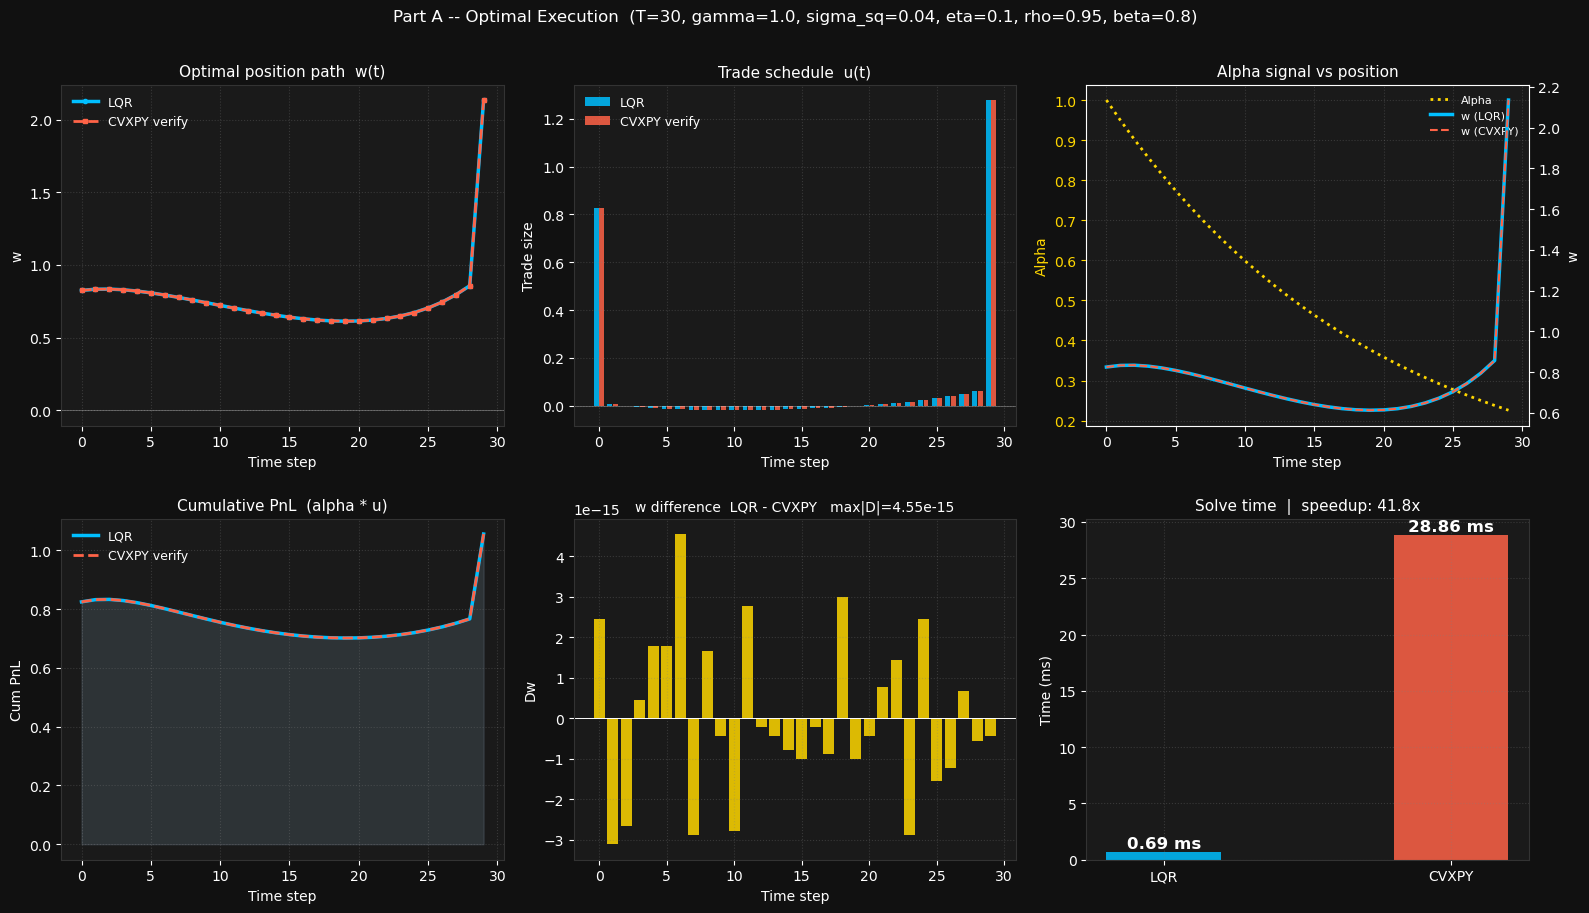

In [4]:
plot_single_asset_results(
    w_lqr=w_lqr_ex, w_cvx=w_cvx_ex,
    u_lqr=u_lqr_ex_w, u_cvx=u_cvx_ex_w,
    alphas=alphas_ex, diff=diff_ex,
    time_lqr=time_lqr_ex, time_cvx=time_cvx_ex, speedup=speedup_ex,
    suptitle=(
        f'Part A -- Optimal Execution  '
        f'(T={T_ex}, gamma={gamma_ex}, sigma_sq={sigma_sq_ex}, '
        f'eta={eta_ex}, rho={rho_ex}, beta={beta_ex})'
    ),
    save_path='result/execution_results.png',
)
plt.show()

---
# Part B — Multi-Asset Markowitz Portfolio

## Problem Overview

At each step the agent holds a portfolio $w_t \in \mathbb{R}^n$ and chooses trades $u_t$ to balance:

| Force | Intuition | Cost term |
|:---|:---|:---|
| **Expected return** | Move toward high-$\mu$ assets | $-\mu^\top w_{t+1}$ (reward) |
| **Risk** | Penalise portfolio variance | $\frac{\lambda}{2}\, w_{t+1}^\top \Sigma\, w_{t+1}$ |
| **Transaction cost** | Penalise large trades | $\frac{\gamma_{tc}}{2}\|u_t\|^2$ |

---
## State, Control & Dynamics

$$s_t = \begin{bmatrix} w_t \\ 1 \end{bmatrix} \in \mathbb{R}^{n+1} \qquad u_t = \Delta w_t \in \mathbb{R}^n$$

| Symbol | Meaning |
|:---|:---|
| $w_t \in \mathbb{R}^n$ | Portfolio weights across $n$ assets |
| $1$ | Constant augmentation dimension — encodes the linear $\mu$ reward as a quadratic cross-term |
| $u_t$ | Trade vector — how much to buy/sell each asset |

The full transition $s_{t+1} = A s_t + B u_t$ is:

$$\begin{bmatrix} w_{t+1} \\ 1 \end{bmatrix}
=
\underbrace{\begin{bmatrix} I_n & 0 \\ 0 & 1 \end{bmatrix}}_{A = I_{n+1}}
\begin{bmatrix} w_t \\ 1 \end{bmatrix}
+
\underbrace{\begin{bmatrix} I_n \\ 0 \end{bmatrix}}_{B}
u_t$$

> **Key insight:** The constant `1` dimension never changes ($A_{n,n}=1$, $B_{n,:}=0$).
> It lets us encode the linear term $-\mu^\top w$ inside $Q$ and $M$ as quadratic cross-terms,
> so the standard LQR backward induction applies without modification.

---
## LQR Cost Matrices

Per-step cost: $\;s_t^\top Q\, s_t \;+\; u_t^\top R\, u_t \;+\; 2\,s_t^\top M\, u_t$

| Matrix | Shape | Value | What it encodes |
|:---|:---|:---|:---|
| $Q$ | $(n{+}1, n{+}1)$ | `Q[:n,:n]=0.5λΣ`, `Q[n,:n]=Q[:n,n]=-0.5μ` | Risk + expected return (via constant dim) |
| $R$ | $(n, n)$ | `0.5γ_tc I + 0.5λΣ` | Transaction cost + risk from the trade itself |
| $M$ | $(n{+}1, n)$ | `M[:n,:]=0.5λΣ`, `M[n,:]=-0.5μ` | Risk cross-term + return-from-trade |
| $s_0$ | $(n{+}1,)$ | `[w0, 1]` | Initial weights + constant augmentation |

---


## B1  Parameters & Matrices

In [5]:
# ════════════════════════════════════════════════════════
#  Option 1 — random parameters
# ════════════════════════════════════════════════════════
T_mw     = 30
n_assets = 5
lam      = 2.0
gamma_tc = 0.5
seed     = 42

rng   = np.random.default_rng(seed)
L     = rng.standard_normal((n_assets, n_assets)) * 0.1
Sigma = L @ L.T + np.diag(rng.uniform(0.01, 0.05, n_assets))
mu    = rng.uniform(0.002, 0.010, n_assets)
w0_mw = rng.uniform(-0.05, 0.05, n_assets)

# ════════════════════════════════════════════════════════
#  Option 2 — paste your own matrices
#  mu    = np.array([...])         # (n,)
#  Sigma = np.array([[...], ...])  # (n, n) positive definite
#  w0_mw = np.array([...])         # (n,) initial weights
# ════════════════════════════════════════════════════════

A_mw, B_mw, Q_mw, R_mw, M_mw, s0_mw = build_markowitz_matrices(
    mu=mu, Sigma=Sigma, lam=lam, gamma_tc=gamma_tc, w0=w0_mw,
)

print(f'n={n_assets} assets  T={T_mw}  lam={lam}  gamma_tc={gamma_tc}')
print(f'mu           = {mu.round(4)}')
print(f'w0           = {w0_mw.round(4)}')
print(f'Sigma (diag) = {np.diag(Sigma).round(4)}')

n=5 assets  T=30  lam=2.0  gamma_tc=0.5
mu           = [0.008  0.0097 0.0046 0.005  0.0058]
w0           = [-0.0311 -0.037  -0.0024 -0.0273  0.017 ]
Sigma (diag) = [0.0821 0.0541 0.0405 0.0419 0.0593]


## B2  Solve (LQR) + Verify (CVXPY)

In [6]:
# ── LQR — median timing over N_REPEAT runs ───────────────
N_REPEAT = 100

times_lqr = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    result_mw = solve_and_execute_lqr(T_mw, A_mw, B_mw, Q_mw, R_mw, M_mw, s0_mw)
    times_lqr.append((time.perf_counter() - t0) * 1000)

time_lqr_mw = np.median(times_lqr)
# Extract state path and drop augmented dimension
s_lqr_mw = result_mw.s_path
w_lqr_mw = s_lqr_mw[:, :n_assets]   # drop augmented dim

# ── CVXPY — median timing over N_REPEAT runs ─────────────
# Wrapped in a function so CVXPY builds a completely fresh
# problem each call — avoids solver caching distorting timing.
def _solve_cvxpy_markowitz(T, mu, Sigma, lam, gamma_tc, w0):
    n_ = len(mu)
    W  = cp.Variable((T + 1, n_))
    U  = cp.Variable((T, n_))
    con  = [W[0] == w0]
    cost = 0
    for t in range(T):
        con.append(W[t+1] == W[t] + U[t])
        cost += (-mu @ W[t+1]
                 + 0.5 * lam      * cp.quad_form(W[t+1], Sigma)
                 + 0.5 * gamma_tc * cp.sum_squares(U[t]))
    cp.Problem(cp.Minimize(cost), con).solve(
        solver=cp.OSQP, warm_starting=False)
    return W.value

times_cvx = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    w_cvx_mw = _solve_cvxpy_markowitz(T_mw, mu, Sigma, lam, gamma_tc, w0_mw)
    times_cvx.append((time.perf_counter() - t0) * 1000)

time_cvx_mw = np.median(times_cvx)

def compute_obj(w_path, mu, Sigma, lam, gamma_tc):
    total = 0.0
    for t in range(1, len(w_path)):
        dw = w_path[t] - w_path[t-1]
        total += (mu @ w_path[t]
                  - 0.5 * lam      * w_path[t] @ Sigma @ w_path[t]
                  - 0.5 * gamma_tc * dw @ dw)
    return total

obj_lqr    = compute_obj(w_lqr_mw, mu, Sigma, lam, gamma_tc)
obj_cvx    = compute_obj(w_cvx_mw, mu, Sigma, lam, gamma_tc)
speedup_mw = time_cvx_mw / time_lqr_mw

from IPython.display import Markdown, display
display(Markdown(
    f'### Multi-Asset Markowitz, n={n_assets}\n\n'
    f'| Method | Time (ms) | Objective | Speedup |\n'
    f'|:---|---:|---:|---:|\n'
    f'| **CVXPY (verify)** | {time_cvx_mw:.2f} | {obj_cvx:.6f} | 1x |\n'
    f'| **LQR (main)** | {time_lqr_mw:.2f} | {obj_lqr:.6f} | **~{speedup_mw:.0f}x** |'
))

### Multi-Asset Markowitz, n=5

| Method | Time (ms) | Objective | Speedup |
|:---|---:|---:|---:|
| **CVXPY (verify)** | 108.26 | 0.030336 | 1x |
| **LQR (main)** | 0.81 | 0.030336 | **~133x** |

In [7]:
# ── Scaling Analysis: Speedup for each n ─────────────────
print("\nRunning scaling analysis across different asset counts...")

n_list = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10
scaling_results = []

for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_  = np.random.default_rng(seed_)
        L_    = rng_.standard_normal((n_, n_)) * 0.1
        Sig_  = L_ @ L_.T + np.diag(rng_.uniform(0.01, 0.05, n_))
        mu_   = rng_.uniform(0.002, 0.010, n_)
        w0_   = rng_.uniform(-0.05, 0.05, n_)

        A_, B_, Q_, R_, M_, s0_ = build_markowitz_matrices(
            mu=mu_, Sigma=Sig_, lam=lam, gamma_tc=gamma_tc, w0=w0_,
        )

        t0 = time.perf_counter()
        result_ = solve_and_execute_lqr(T_mw, A_, B_, Q_, R_, M_, s0_)
        ts_lqr.append((time.perf_counter()-t0)*1000)

        t0 = time.perf_counter()
        _solve_cvxpy_markowitz(T_mw, mu_, Sig_, lam, gamma_tc, w0_)
        ts_cvx.append((time.perf_counter()-t0)*1000)

    lqr_med = np.median(ts_lqr)
    cvx_med = np.median(ts_cvx)
    speedup = cvx_med / lqr_med
    
    scaling_results.append({
        'n': n_,
        'lqr_time': lqr_med,
        'cvx_time': cvx_med,
        'speedup': speedup
    })
    print(f"  n={n_:2d}: LQR={lqr_med:6.2f}ms, CVXPY={cvx_med:6.2f}ms, Speedup={speedup:.1f}x")

# Display scaling results table
display(Markdown(
    '\n### Scaling Analysis: Speedup by Number of Assets\n\n'
    '| Assets (n) | LQR Time (ms) | CVXPY Time (ms) | Speedup |\n'
    '|:---:|---:|---:|---:|\n' +
    '\n'.join([
        f"| {r['n']} | {r['lqr_time']:.2f} | {r['cvx_time']:.2f} | **{r['speedup']:.1f}x** |"
        for r in scaling_results
    ])
))


Running scaling analysis across different asset counts...
  n= 2: LQR=  0.85ms, CVXPY=104.25ms, Speedup=122.2x
  n= 3: LQR=  0.85ms, CVXPY=105.95ms, Speedup=125.1x
  n= 5: LQR=  0.95ms, CVXPY=110.70ms, Speedup=116.1x
  n= 7: LQR=  0.90ms, CVXPY=115.38ms, Speedup=128.9x
  n=10: LQR=  1.06ms, CVXPY=119.61ms, Speedup=112.8x
  n=15: LQR=  1.12ms, CVXPY=130.24ms, Speedup=116.1x
  n=20: LQR=  1.43ms, CVXPY=147.31ms, Speedup=103.2x



### Scaling Analysis: Speedup by Number of Assets

| Assets (n) | LQR Time (ms) | CVXPY Time (ms) | Speedup |
|:---:|---:|---:|---:|
| 2 | 0.85 | 104.25 | **122.2x** |
| 3 | 0.85 | 105.95 | **125.1x** |
| 5 | 0.95 | 110.70 | **116.1x** |
| 7 | 0.90 | 115.38 | **128.9x** |
| 10 | 1.06 | 119.61 | **112.8x** |
| 15 | 1.12 | 130.24 | **116.1x** |
| 20 | 1.43 | 147.31 | **103.2x** |

## B3  Plots

Saved: result/markowitz_results.png


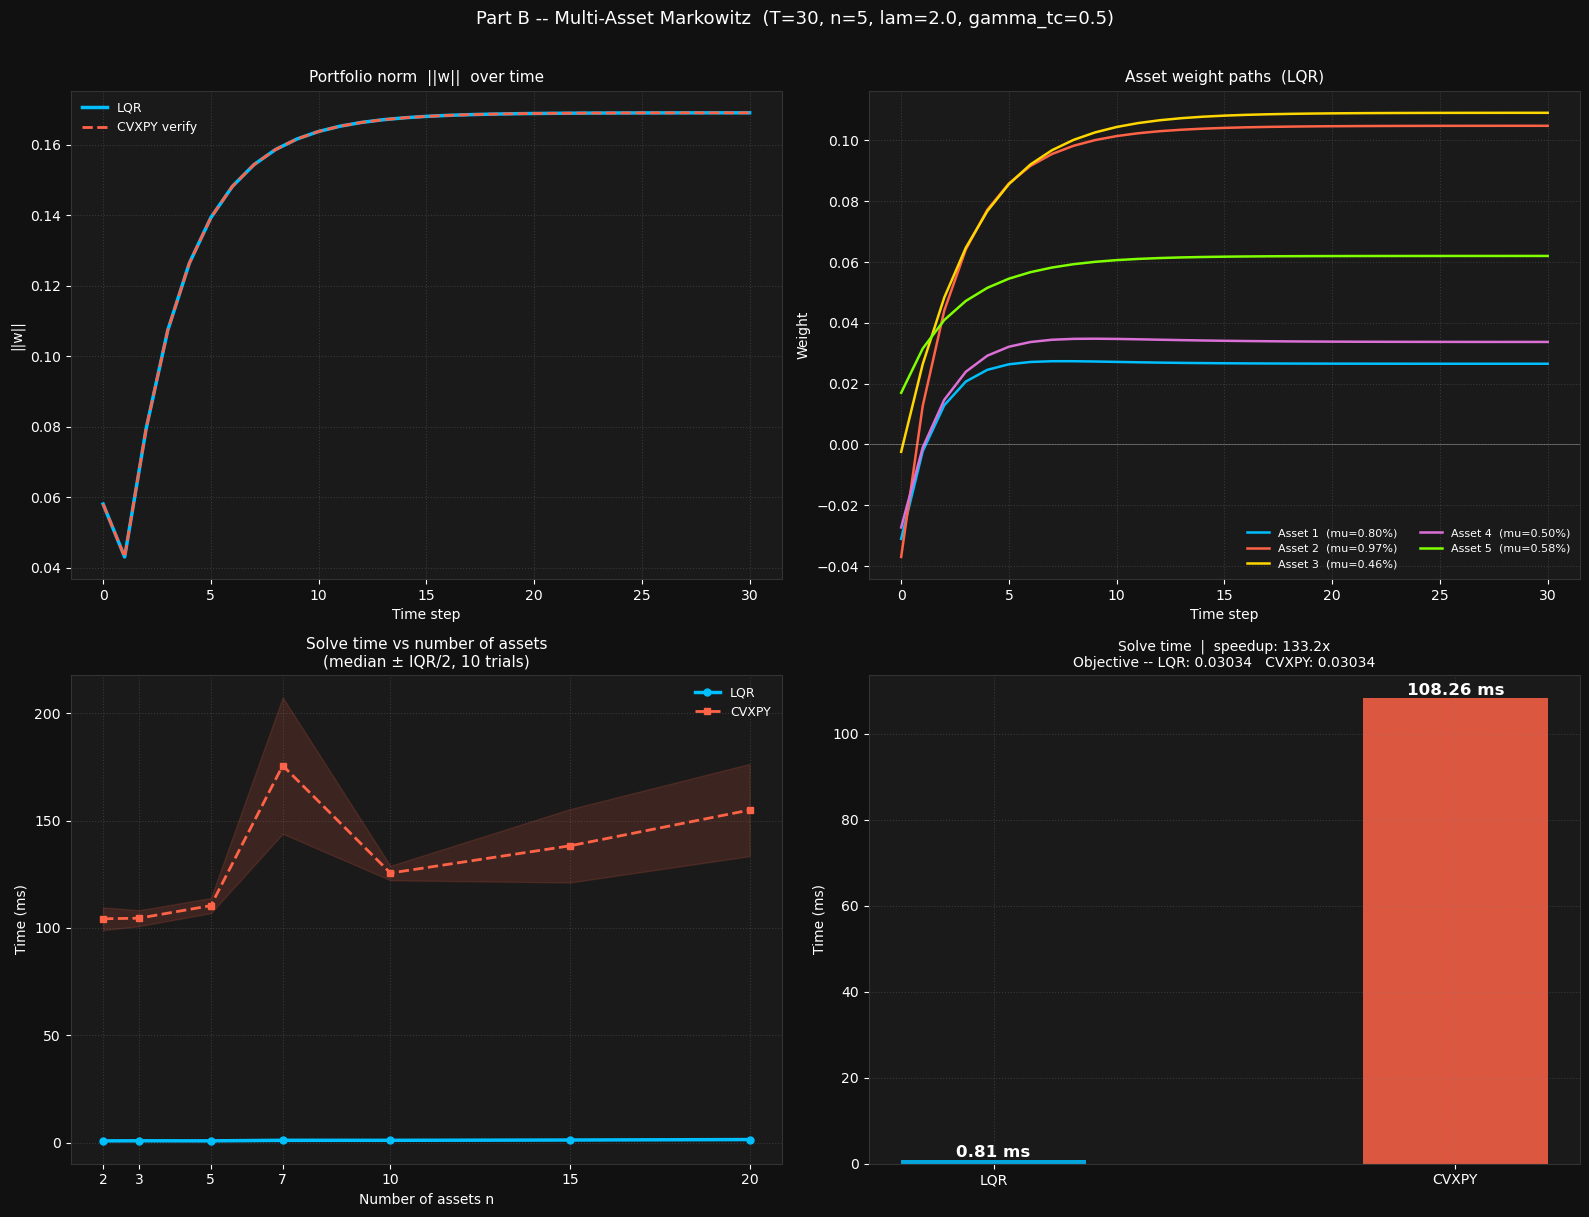

In [8]:
# ── Scaling timing data (computation kept here; plotting handled by visual.py) ──
n_list   = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10

def _solve_cvxpy_scaling(n__, T__, mu__, Sig__, lam__, gtc__, w0__):
    """Isolated function scope — guarantees fresh CVXPY problem."""
    W__ = cp.Variable((T__+1, n__))
    U__ = cp.Variable((T__, n__))
    c__ = [W__[0] == w0__]
    cs  = 0
    for t__ in range(T__):
        c__.append(W__[t__+1] == W__[t__] + U__[t__])
        cs += (-mu__ @ W__[t__+1]
               + 0.5*lam__*cp.quad_form(W__[t__+1], Sig__)
               + 0.5*gtc__*cp.sum_squares(U__[t__]))
    cp.Problem(cp.Minimize(cs), c__).solve(
        solver=cp.OSQP, warm_starting=False)

lqr_ms, cvx_ms = [], []
for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_  = np.random.default_rng(seed_)
        L_    = rng_.standard_normal((n_, n_)) * 0.1
        Sig_  = L_ @ L_.T + np.diag(rng_.uniform(0.01, 0.05, n_))
        mu_   = rng_.uniform(0.002, 0.010, n_)
        w0_   = rng_.uniform(-0.05, 0.05, n_)

        A_, B_, Q_, R_, M_, s0_ = build_markowitz_matrices(
            mu=mu_, Sigma=Sig_, lam=lam, gamma_tc=gamma_tc, w0=w0_,
        )

        t0 = time.perf_counter()
        result_scale = solve_and_execute_lqr(T_mw, A_, B_, Q_, R_, M_, s0_)
        ts_lqr.append((time.perf_counter()-t0)*1000)

        t0 = time.perf_counter()
        _solve_cvxpy_scaling(n_, T_mw, mu_, Sig_, lam, gamma_tc, w0_)
        ts_cvx.append((time.perf_counter()-t0)*1000)

    lqr_ms.append((np.median(ts_lqr),
                   (np.percentile(ts_lqr, 75) - np.percentile(ts_lqr, 25)) / 2))
    cvx_ms.append((np.median(ts_cvx),
                   (np.percentile(ts_cvx, 75) - np.percentile(ts_cvx, 25)) / 2))

scaling_mw = {
    'n_list':  n_list,
    'lqr_med': [x[0] for x in lqr_ms],
    'lqr_iqr': [x[1] for x in lqr_ms],
    'cvx_med': [x[0] for x in cvx_ms],
    'cvx_iqr': [x[1] for x in cvx_ms],
}

plot_multi_asset_results(
    W_lqr=w_lqr_mw, W_cvx=w_cvx_mw,
    mu=mu,
    time_lqr=time_lqr_mw, time_cvx=time_cvx_mw, speedup=speedup_mw,
    obj_lqr=obj_lqr, obj_cvx=obj_cvx,
    scaling=scaling_mw,
    suptitle=(
        f'Part B -- Multi-Asset Markowitz  '
        f'(T={T_mw}, n={n_assets}, lam={lam}, gamma_tc={gamma_tc})'
    ),
    save_path='result/markowitz_results.png',
)
plt.show()

# Part C — Given-Weight Extension

This section adds **given target-weight tracking** in the same demo style:

- **Single-asset** tracking to scalar target `w_given`
- **Multi-asset** tracking to vector target `w_given_vec`

Model form is kept close to the augmented-state setup used in Part B (`[w, 1]`) and solved by `solve_and_execute_lqr`, with CVXPY verification.

T=30, w0=0.0, w_given=0.25, kappa=0.04, gamma_tc=0.1, k_terminal=80.0
single-asset DP solve+execute: 1.20 ms
single-asset CVXPY solve: 104.77 ms, status=optimal
|w_T - w_given| (DP)    = 3.224643e-12
|w_T - w_given| (CVXPY) = 3.224643e-12
max |w_DP - w_CVX|      = 2.78e-17
Saved: result/givenweight_single_results.png


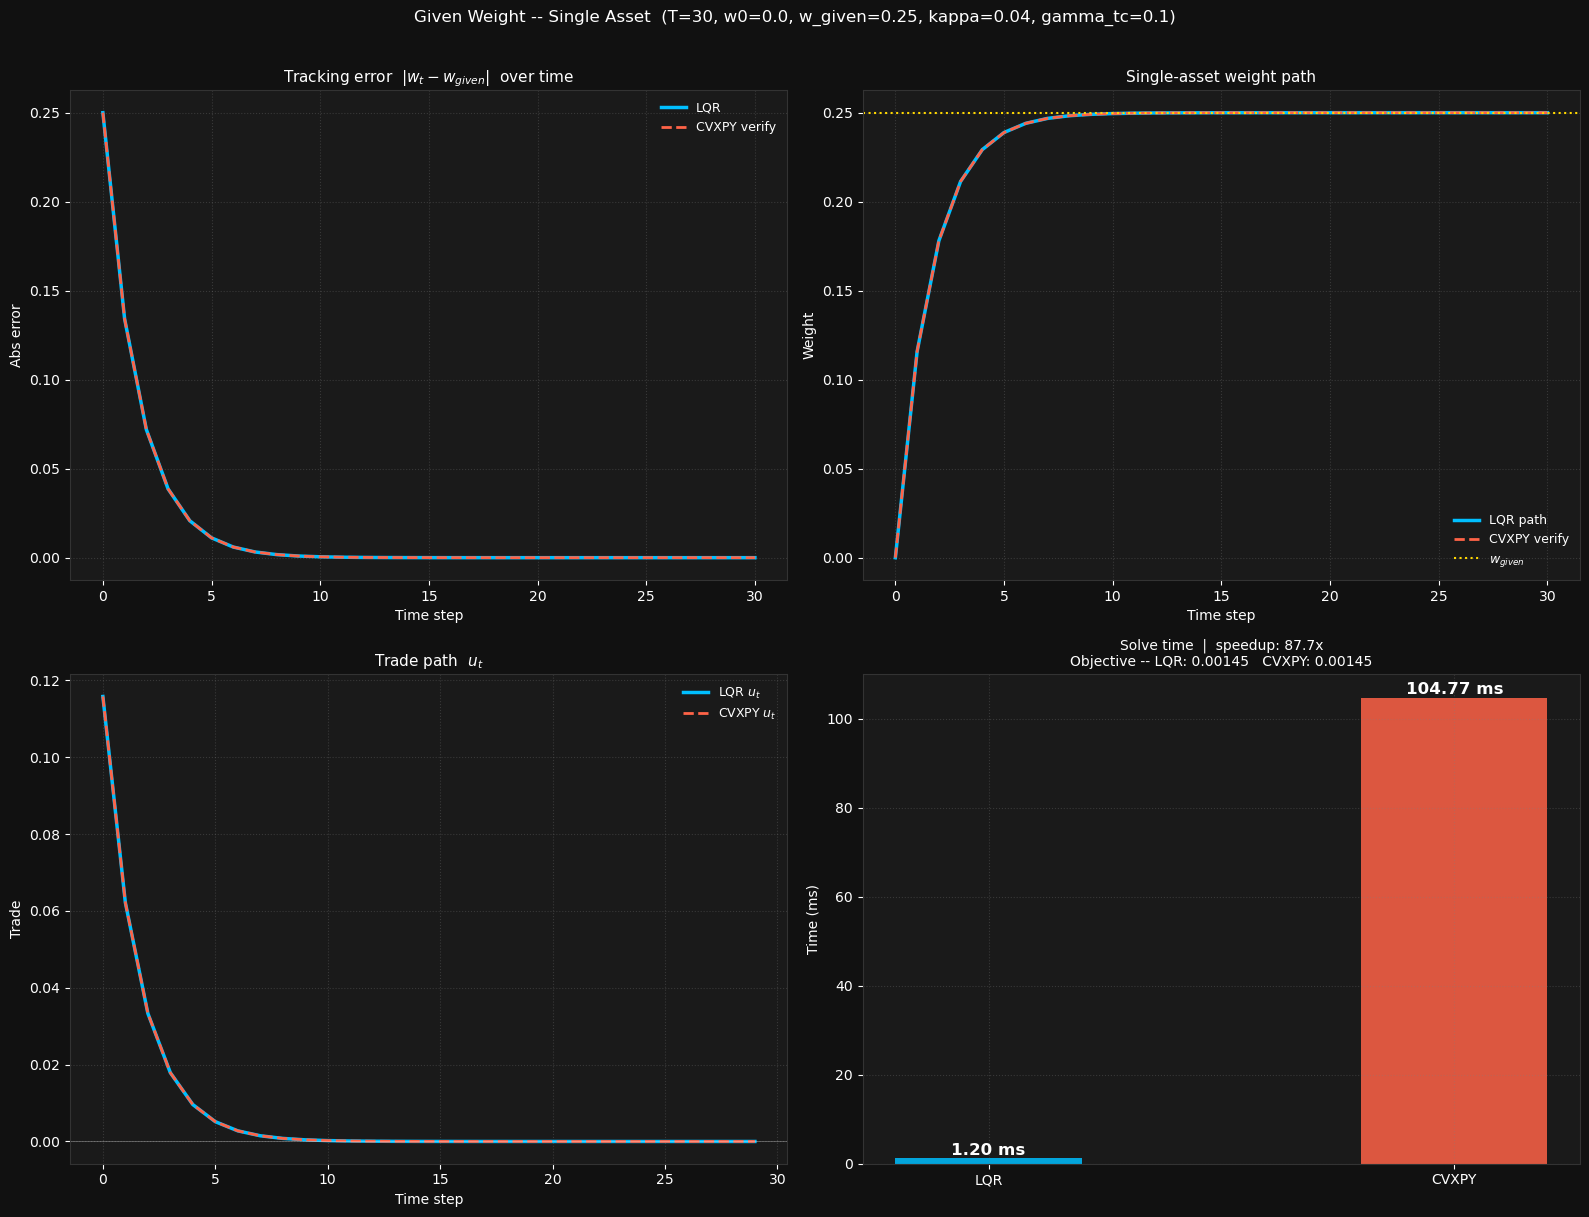

In [9]:
# ════════════════════════════════════════════════════════
#  Given Weight — Single Asset
# ════════════════════════════════════════════════════════
T_gw = 30
w0_gw = 0.0
w_given_gw = 0.25

# keep parameter style close to the first LQR block
gamma_gw = 1.0
sigma_sq_gw = 0.04
eta_gw = 0.1
k_terminal_gw = 80.0

kappa_gw = gamma_gw * sigma_sq_gw
gamma_tc_gw = eta_gw

A_gw, B_gw, Q_gw, R_gw, M_gw, s0_gw, P_T_gw = build_given_weight_single_matrices(
    w_given=w_given_gw,
    kappa=kappa_gw,
    gamma_tc=gamma_tc_gw,
    k_terminal=k_terminal_gw,
    w0=w0_gw,
)

print(
    f"T={T_gw}, w0={w0_gw}, w_given={w_given_gw}, "
    f"kappa={kappa_gw}, gamma_tc={gamma_tc_gw}, k_terminal={k_terminal_gw}"
)

# DP/LQR
t0 = time.perf_counter()
result_gw = solve_and_execute_lqr(
    T_gw, A_gw, B_gw, Q_gw, R_gw, M_gw, s0_gw, P_terminal=P_T_gw
)
time_lqr_gw = (time.perf_counter() - t0) * 1000
print(f"single-asset DP solve+execute: {time_lqr_gw:.2f} ms")

w_path_gw = result_gw.s_path[:, 0]
u_path_gw = result_gw.u_path[:, 0]

# CVXPY benchmark
W_gw = cp.Variable(T_gw + 1)
U_gw = cp.Variable(T_gw)
cons_gw = [W_gw[0] == w0_gw]
for t in range(T_gw):
    cons_gw.append(W_gw[t + 1] == W_gw[t] + U_gw[t])

cost_gw = 0
for t in range(T_gw):
    cost_gw += 0.5 * kappa_gw * cp.square(W_gw[t + 1] - w_given_gw)
    cost_gw += 0.5 * gamma_tc_gw * cp.square(U_gw[t])
cost_gw += 0.5 * k_terminal_gw * cp.square(W_gw[T_gw] - w_given_gw)

prob_gw = cp.Problem(cp.Minimize(cost_gw), cons_gw)
t0 = time.perf_counter()
prob_gw.solve(solver=cp.OSQP, verbose=False)
time_cvx_gw = (time.perf_counter() - t0) * 1000
print(f"single-asset CVXPY solve: {time_cvx_gw:.2f} ms, status={prob_gw.status}")

w_cvx_gw = np.asarray(W_gw.value)
u_cvx_gw = np.asarray(U_gw.value)
speedup_gw = time_cvx_gw / max(time_lqr_gw, 1e-12)

obj_gw_dp = (
    np.sum(0.5 * kappa_gw * (w_path_gw[1:] - w_given_gw) ** 2 + 0.5 * gamma_tc_gw * u_path_gw ** 2)
    + 0.5 * k_terminal_gw * (w_path_gw[-1] - w_given_gw) ** 2
)
obj_gw_cvx = (
    np.sum(0.5 * kappa_gw * (w_cvx_gw[1:] - w_given_gw) ** 2 + 0.5 * gamma_tc_gw * u_cvx_gw ** 2)
    + 0.5 * k_terminal_gw * (w_cvx_gw[-1] - w_given_gw) ** 2
)

print(f"|w_T - w_given| (DP)    = {abs(w_path_gw[-1] - w_given_gw):.6e}")
print(f"|w_T - w_given| (CVXPY) = {abs(w_cvx_gw[-1] - w_given_gw):.6e}")
print(f"max |w_DP - w_CVX|      = {np.max(np.abs(w_path_gw - w_cvx_gw)):.2e}")

plot_single_asset_results(
    w_lqr=w_path_gw, w_cvx=w_cvx_gw,
    u_lqr=u_path_gw, u_cvx=u_cvx_gw,
    w_given=w_given_gw,
    time_lqr=time_lqr_gw, time_cvx=time_cvx_gw, speedup=speedup_gw,
    obj_lqr=obj_gw_dp, obj_cvx=obj_gw_cvx,
    suptitle=(
        f'Given Weight -- Single Asset  '
        f'(T={T_gw}, w0={w0_gw}, w_given={w_given_gw}, '
        f'kappa={kappa_gw}, gamma_tc={gamma_tc_gw})'
    ),
    save_path='result/givenweight_single_results.png',
)
plt.show()

In [10]:
# ════════════════════════════════════════════════════════
#  Given Weight — Multi Asset
# ════════════════════════════════════════════════════════
T_gwm = 30
n_assets_gwm = 5
kappa_gwm = 2.0
gamma_tc_gwm = 0.5
k_terminal_gwm = 80.0
seed_gwm = 42

rng = np.random.default_rng(seed_gwm)

# given target vector (same random-parameter style as Markowitz block)
w_given_gwm = rng.uniform(0.05, 0.35, n_assets_gwm)
w_given_gwm = w_given_gwm / np.sum(w_given_gwm)

# simple initialization (no optimization): random long-only then normalize
w0_gwm = rng.uniform(0.0, 0.40, n_assets_gwm)
w0_gwm = w0_gwm / np.sum(w0_gwm)

n = n_assets_gwm

A_gwm, B_gwm, Q_gwm, R_gwm, M_gwm, s0_gwm, P_T_gwm = build_given_weight_multi_matrices(
    w_given=w_given_gwm,
    kappa=kappa_gwm,
    gamma_tc=gamma_tc_gwm,
    k_terminal=k_terminal_gwm,
    w0=w0_gwm,
)

print(f"n={n_assets_gwm} assets  T={T_gwm}  kappa={kappa_gwm}  gamma_tc={gamma_tc_gwm}")
print(f"w_given      = {w_given_gwm.round(4)}")
print(f"w0 (simple)  = {w0_gwm.round(4)}")


n=5 assets  T=30  kappa=2.0  gamma_tc=0.5
w_given      = [0.2545 0.1638 0.2774 0.2338 0.0706]
w0 (simple)  = [0.3146 0.2454 0.2535 0.0413 0.1452]


In [11]:

# DP/LQR
t0 = time.perf_counter()
result_gwm = solve_and_execute_lqr(
    T_gwm, A_gwm, B_gwm, Q_gwm, R_gwm, M_gwm, s0_gwm, P_terminal=P_T_gwm
)
print(f"multi-asset DP solve+execute: {(time.perf_counter() - t0) * 1000:.2f} ms")

W_path_gwm = result_gwm.s_path[:, :n]
err_gwm = np.linalg.norm(W_path_gwm - w_given_gwm, axis=1)

# CVXPY benchmark
Wm = cp.Variable((T_gwm + 1, n))
Um = cp.Variable((T_gwm, n))
cons_m = [Wm[0] == w0_gwm]
for t in range(T_gwm):
    cons_m.append(Wm[t + 1] == Wm[t] + Um[t])

cost_m = 0
for t in range(T_gwm):
    cost_m += 0.5 * kappa_gwm * cp.sum_squares(Wm[t + 1] - w_given_gwm)
    cost_m += 0.5 * gamma_tc_gwm * cp.sum_squares(Um[t])
cost_m += 0.5 * k_terminal_gwm * cp.sum_squares(Wm[T_gwm] - w_given_gwm)

prob_m = cp.Problem(cp.Minimize(cost_m), cons_m)
t0 = time.perf_counter()
prob_m.solve(solver=cp.OSQP, verbose=False)
print(f"multi-asset CVXPY solve: {(time.perf_counter() - t0) * 1000:.2f} ms, status={prob_m.status}")

W_cvx_gwm = np.asarray(Wm.value)
err_cvx_gwm = np.linalg.norm(W_cvx_gwm - w_given_gwm, axis=1)

print(f"||w_T - w_given||_2 (DP)    = {err_gwm[-1]:.6e}")
print(f"||w_T - w_given||_2 (CVXPY) = {err_cvx_gwm[-1]:.6e}")
print(f"max |W_DP - W_CVX|          = {np.max(np.abs(W_path_gwm - W_cvx_gwm)):.2e}")


multi-asset DP solve+execute: 1.07 ms
multi-asset CVXPY solve: 85.54 ms, status=optimal
||w_T - w_given||_2 (DP)    = 2.775558e-17
||w_T - w_given||_2 (CVXPY) = 0.000000e+00
max |W_DP - W_CVX|          = 8.88e-16


In [12]:

# Objectives
obj_dp_gwm = (
    np.sum(0.5 * kappa_gwm * np.sum((W_path_gwm[1:] - w_given_gwm) ** 2, axis=1)
           + 0.5 * gamma_tc_gwm * np.sum(np.asarray(result_gwm.u_path) ** 2, axis=1))
    + 0.5 * k_terminal_gwm * np.sum((W_path_gwm[-1] - w_given_gwm) ** 2)
)
obj_cvx_gwm = (
    np.sum(0.5 * kappa_gwm * np.sum((W_cvx_gwm[1:] - w_given_gwm) ** 2, axis=1)
           + 0.5 * gamma_tc_gwm * np.sum(np.asarray(Um.value) ** 2, axis=1))
    + 0.5 * k_terminal_gwm * np.sum((W_cvx_gwm[-1] - w_given_gwm) ** 2)
)

# ── Scaling timing data ─────────────────────────────────────────────
n_list = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10

def _solve_cvxpy_scaling_given(n__, T__, w_given__, kappa__, gamma_tc__, k_terminal__, w0__):
    W__ = cp.Variable((T__ + 1, n__))
    U__ = cp.Variable((T__, n__))
    c__ = [W__[0] == w0__]
    cs = 0
    for t__ in range(T__):
        c__.append(W__[t__ + 1] == W__[t__] + U__[t__])
        cs += (0.5 * kappa__ * cp.sum_squares(W__[t__ + 1] - w_given__)
               + 0.5 * gamma_tc__ * cp.sum_squares(U__[t__]))
    cs += 0.5 * k_terminal__ * cp.sum_squares(W__[T__] - w_given__)
    cp.Problem(cp.Minimize(cs), c__).solve(solver=cp.OSQP, warm_starting=False)

lqr_ms, cvx_ms = [], []
for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_ = np.random.default_rng(seed_)
        w_given_ = rng_.uniform(0.05, 0.35, n_)
        w_given_ = w_given_ / np.sum(w_given_)
        w0_ = rng_.uniform(0.0, 0.40, n_)
        w0_ = w0_ / np.sum(w0_)

        A_, B_, Q_, R_, M_, s0_, P_ = build_given_weight_multi_matrices(
            w_given=w_given_, kappa=kappa_gwm,
            gamma_tc=gamma_tc_gwm, k_terminal=k_terminal_gwm, w0=w0_,
        )

        t0 = time.perf_counter()
        _ = solve_and_execute_lqr(T_gwm, A_, B_, Q_, R_, M_, s0_, P_terminal=P_)
        ts_lqr.append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        _solve_cvxpy_scaling_given(n_, T_gwm, w_given_, kappa_gwm, gamma_tc_gwm, k_terminal_gwm, w0_)
        ts_cvx.append((time.perf_counter() - t0) * 1000)

    lqr_ms.append((np.median(ts_lqr),
                   (np.percentile(ts_lqr, 75) - np.percentile(ts_lqr, 25)) / 2))
    cvx_ms.append((np.median(ts_cvx),
                   (np.percentile(ts_cvx, 75) - np.percentile(ts_cvx, 25)) / 2))

scaling_gwm = {
    'n_list':  n_list,
    'lqr_med': [x[0] for x in lqr_ms],
    'lqr_iqr': [x[1] for x in lqr_ms],
    'cvx_med': [x[0] for x in cvx_ms],
    'cvx_iqr': [x[1] for x in cvx_ms],
}


Saved: result/givenweight_results.png


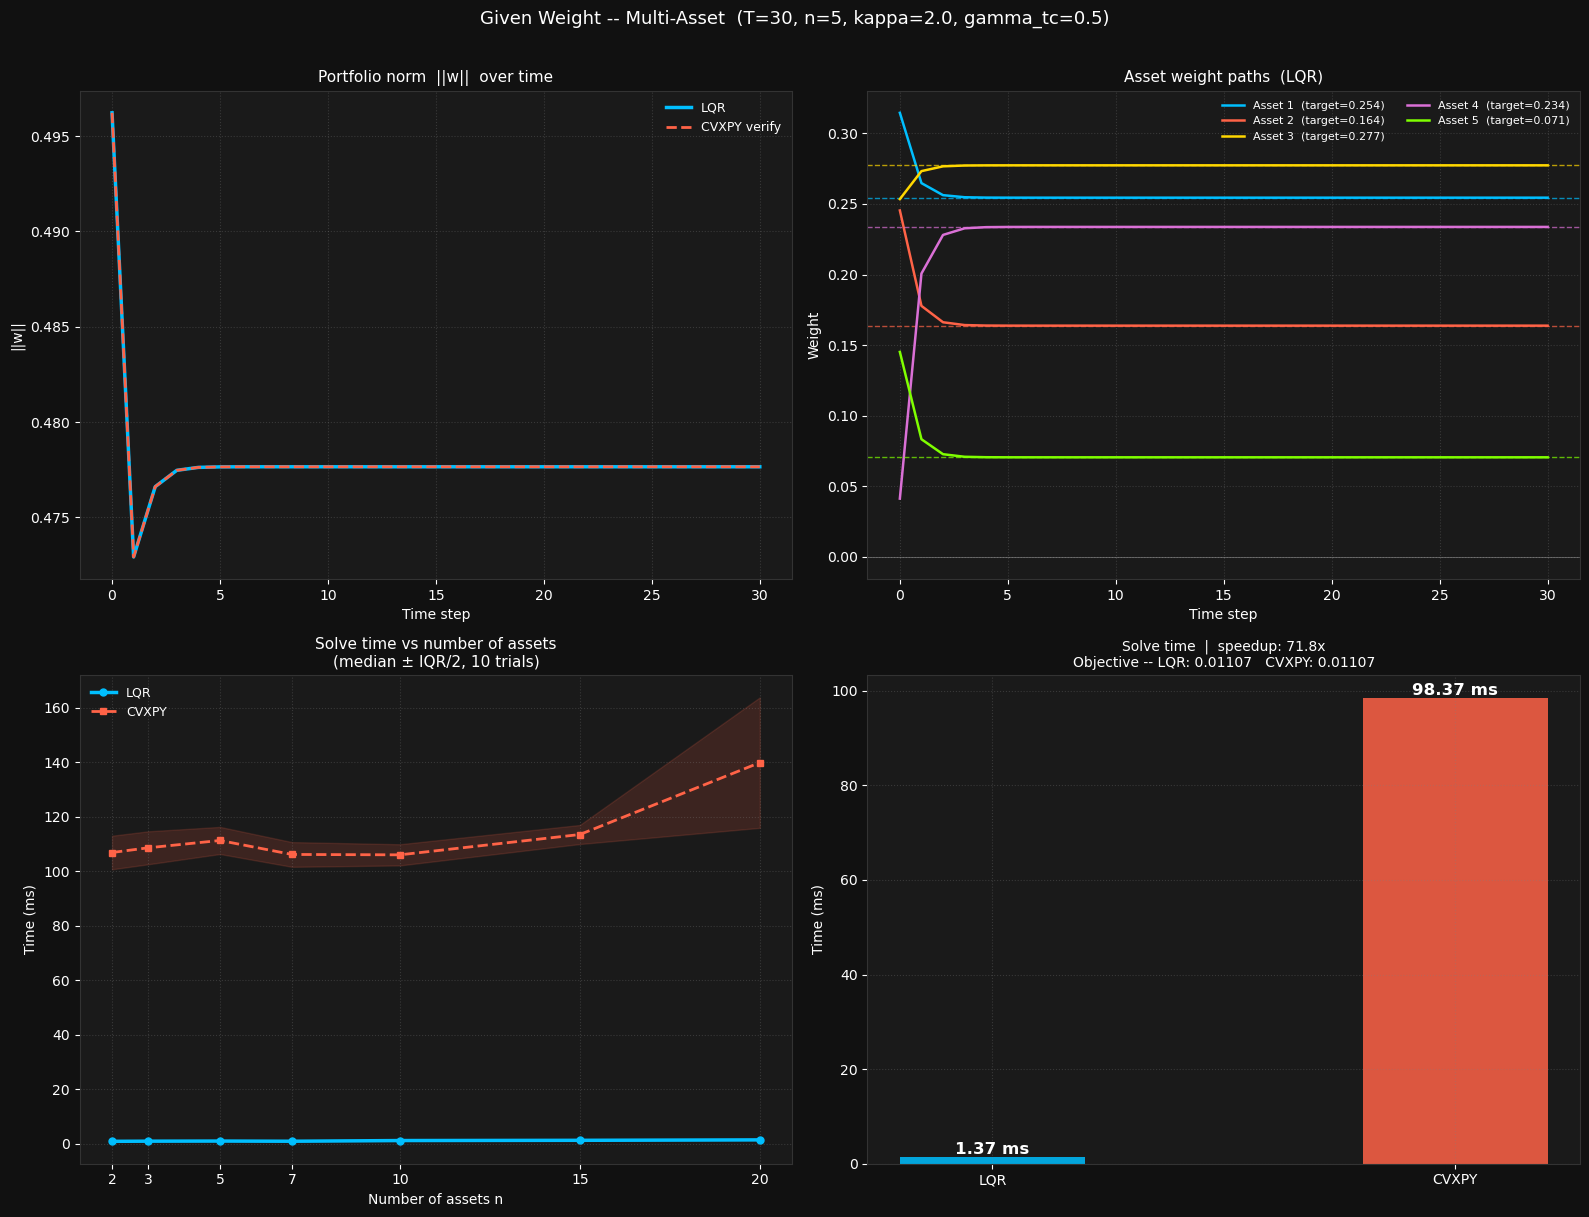

In [13]:

# Re-time the headline solve+CVXPY for the headline timing panel
t0 = time.perf_counter()
_ = solve_and_execute_lqr(T_gwm, A_gwm, B_gwm, Q_gwm, R_gwm, M_gwm, s0_gwm, P_terminal=P_T_gwm)
time_lqr_gwm = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
cp.Problem(cp.Minimize(cost_m), cons_m).solve(solver=cp.OSQP, verbose=False)
time_cvx_gwm = (time.perf_counter() - t0) * 1000

speedup_gwm = time_cvx_gwm / max(time_lqr_gwm, 1e-12)

plot_multi_asset_results(
    W_lqr=W_path_gwm, W_cvx=W_cvx_gwm,
    w_given=w_given_gwm,
    time_lqr=time_lqr_gwm, time_cvx=time_cvx_gwm, speedup=speedup_gwm,
    obj_lqr=obj_dp_gwm, obj_cvx=obj_cvx_gwm,
    scaling=scaling_gwm,
    suptitle=(
        f'Given Weight -- Multi-Asset  '
        f'(T={T_gwm}, n={n_assets_gwm}, kappa={kappa_gwm}, gamma_tc={gamma_tc_gwm})'
    ),
    save_path='result/givenweight_results.png',
)
plt.show()

# Part D — Risk-Parity Target Tracking

## Problem Overview

At each step the agent holds a portfolio $w_t \in \mathbb{R}^n$ and tracks a **static risk-parity target** $w_{\text{RP}}$ obtained by solving the risk-contribution equalisation problem offline:

$$\min_{w \ge 0,\, \mathbf{1}^\top w = 1} \sum_{i=1}^n \!\left(RC_i(w) - \frac{\sigma_p^2(w)}{n}\right)^{\!2}$$

where $RC_i = w_i (\Sigma w)_i$ is asset $i$'s risk contribution and $\sigma_p^2 = w^\top \Sigma w$.

The LQR per-step cost is identical to the Given-Weight multi-asset case (Part C):

$$\frac{\kappa}{2}\|w_{t+1} - w_{\text{RP}}\|^2 + \frac{\gamma_{tc}}{2}\|u_t\|^2$$

No terminal penalty is used ($k_{\text{terminal}} = 0$).

---
## LQR Cost Matrices

| Matrix | Value | What it encodes |
|:---|:---|:---|
| $Q$ | `0.5κ [I, -w_RP; -w_RP', w_RP'w_RP]` | Tracking penalty on $\|w - w_\text{RP}\|^2$ |
| $R$ | `0.5(κ + γ_tc) I` | Transaction cost + tracking cost from the trade |
| $M$ | `0.5κ [I; -w_RP']` | Cross term linking state and control |
| $s_0$ | `[w0; 1]` | Initial weights + constant augmentation |

---

## D1  Parameters & Matrices

In [14]:
from scipy.optimize import minimize

def get_risk_parity_target(Sigma):
    """Compute static risk-parity portfolio weights from covariance matrix.

    Solves: ``min_{w} sum_i (RC_i - sigma_p^2 / n)^2``
    subject to ``sum(w) = 1``, ``w >= 0``.

    Where ``RC_i = w_i * (Sigma w)_i`` is the risk contribution of asset ``i``
    and ``sigma_p^2 = w' Sigma w``.

    Uses inverse-volatility weighting as starting point (classical RP
    approximation) so that the optimizer converges reliably even when asset
    volatilities differ substantially.
    """
    Sigma = np.asarray(Sigma, dtype=float)
    n = Sigma.shape[0]

    def _objective(w):
        port_var = w @ Sigma @ w
        risk_contrib = w * (Sigma @ w)
        return np.sum((risk_contrib - port_var / n) ** 2)

    inv_vol = 1.0 / np.sqrt(np.diag(Sigma))
    w_init  = inv_vol / inv_vol.sum()

    res = minimize(
        _objective,
        x0=w_init,
        method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        options={'ftol': 1e-12, 'maxiter': 2000},
    )
    return res.x



In [15]:
# ── D1  Parameters & Matrices ──────────────────────────────────────────
# Problem dimensions
n_rp  = 5      # number of assets
T_rp  = 30     # horizon

# Parameters
kappa_rp    = 2.0   # tracking-error penalty
gamma_tc_rp = 0.5   # transaction-cost penalty

# Covariance matrix: assets with deliberately spread volatilities (5% → 40%)
# so that risk-parity weights are visibly unequal.
vols = np.array([0.05, 0.10, 0.18, 0.28, 0.40])   # annualised vol per asset
rho  = 0.25                                         # constant pairwise correlation
corr = rho * np.ones((n_rp, n_rp)) + (1 - rho) * np.eye(n_rp)
Sigma_rp = np.diag(vols) @ corr @ np.diag(vols)

# Initial portfolio: equal-weight (far from risk-parity target)
w0_rp = np.ones(n_rp) / n_rp
n_rp  = 5      # number of assets
T_rp  = 30     # horizon

# Parameters
kappa_rp    = 2.0   # tracking-error penalty
gamma_tc_rp = 0.5   # transaction-cost penalty

# Covariance matrix: assets with deliberately spread volatilities (5% → 40%)
# so that risk-parity weights are visibly unequal.
vols = np.array([0.05, 0.10, 0.18, 0.28, 0.40])   # annualised vol per asset
rho  = 0.25                                         # constant pairwise correlation
corr = rho * np.ones((n_rp, n_rp)) + (1 - rho) * np.eye(n_rp)
Sigma_rp = np.diag(vols) @ corr @ np.diag(vols)

# Initial portfolio: equal-weight (far from risk-parity target)
w0_rp = np.ones(n_rp) / n_rp

# ── Compute risk-parity target ──────────────────────────────────────────
w_rp = get_risk_parity_target(Sigma_rp)

print("Risk-parity target weights:")
for i, wi in enumerate(w_rp):
    rc = wi * (Sigma_rp @ w_rp)[i]
    print(f"  Asset {i+1}: w={wi:.4f}  RC={rc:.6f}")
print(f"\nSum of weights: {w_rp.sum():.6f}")
print(f"Max |RC_i - RC_bar|: {np.max(np.abs(w_rp*(Sigma_rp@w_rp) - w_rp@Sigma_rp@w_rp/n_rp)):.2e}")

# ── Build LQR matrices ─────────────────────────────────────────────────
A_rp, B_rp, Q_rp, R_rp, M_rp, s0_rp = build_risk_parity_matrices(
    w_rp=w_rp, kappa=kappa_rp, gamma_tc=gamma_tc_rp, w0=w0_rp
)

print("\nMatrix shapes:", {
    "A": A_rp.shape, "B": B_rp.shape, "Q": Q_rp.shape,
    "R": R_rp.shape, "M": M_rp.shape, "s0": s0_rp.shape,
})

Risk-parity target weights:
  Asset 1: w=0.4805  RC=0.001154
  Asset 2: w=0.2402  RC=0.001154
  Asset 3: w=0.1335  RC=0.001154
  Asset 4: w=0.0858  RC=0.001154
  Asset 5: w=0.0601  RC=0.001154

Sum of weights: 1.000000
Max |RC_i - RC_bar|: 2.17e-19

Matrix shapes: {'A': (6, 6), 'B': (6, 5), 'Q': (6, 6), 'R': (5, 5), 'M': (6, 5), 's0': (6,)}


## D2  Solve: LQR vs CVXPY

In [16]:
# ── D2  Solve: LQR vs CVXPY ───────────────────────────────────────────
import time
import cvxpy as cp

# ── LQR ────────────────────────────────────────────────────────────────
t0 = time.perf_counter()
res_rp = solve_and_execute_lqr(T_rp, A_rp, B_rp, Q_rp, R_rp, M_rp, s0_rp)
time_lqr_rp = (time.perf_counter() - t0) * 1000

W_lqr_rp = res_rp.s_path[:, :n_rp]
U_lqr_rp = res_rp.u_path

# ── CVXPY ──────────────────────────────────────────────────────────────
def _solve_cvxpy_rp(T, w_rp_target, kappa, gamma_tc, w0):
    n = len(w_rp_target)
    W = cp.Variable((T + 1, n))
    U = cp.Variable((T, n))
    cost = 0
    constraints = [W[0] == w0]
    for t in range(T):
        constraints.append(W[t + 1] == W[t] + U[t])
        cost += 0.5 * kappa    * cp.sum_squares(W[t + 1] - w_rp_target)
        cost += 0.5 * gamma_tc * cp.sum_squares(U[t])
    cp.Problem(cp.Minimize(cost), constraints).solve(solver=cp.OSQP, verbose=False)
    return W.value, U.value

t0 = time.perf_counter()
W_cvx_rp, U_cvx_rp = _solve_cvxpy_rp(T_rp, w_rp, kappa_rp, gamma_tc_rp, w0_rp)
time_cvx_rp = (time.perf_counter() - t0) * 1000

# ── Objective values ────────────────────────────────────────────────────
def _tracking_cost(W_path, w_target, kappa, gamma_tc):
    total = 0.0
    for t in range(1, len(W_path)):
        err = W_path[t] - w_target
        dw  = W_path[t] - W_path[t - 1]
        total += 0.5 * kappa * float(err @ err) + 0.5 * gamma_tc * float(dw @ dw)
    return total

obj_lqr_rp = _tracking_cost(W_lqr_rp, w_rp, kappa_rp, gamma_tc_rp)
obj_cvx_rp = _tracking_cost(W_cvx_rp, w_rp, kappa_rp, gamma_tc_rp)
speedup_rp = time_cvx_rp / time_lqr_rp if time_lqr_rp > 0 else float('nan')

print(f"LQR   : {time_lqr_rp:.2f} ms   cost = {obj_lqr_rp:.6f}")
print(f"CVXPY : {time_cvx_rp:.2f} ms   cost = {obj_cvx_rp:.6f}")
print(f"Speedup: {speedup_rp:.1f}x")
print(f"max |W_LQR - W_CVX| = {np.max(np.abs(W_lqr_rp - W_cvx_rp)):.2e}")

LQR   : 1.03 ms   cost = 0.024300
CVXPY : 99.51 ms   cost = 0.024300
Speedup: 96.2x
max |W_LQR - W_CVX| = 1.11e-16


## D3  Scaling Analysis

In [17]:
# ── D3  Scaling Analysis ───────────────────────────────────────────────
n_list_rp = [2, 3, 5, 7, 10, 15, 20]
n_trials   = 10
lqr_times_rp, cvx_times_rp = [], []

for n_trial in n_list_rp:
    dp_t, cx_t = [], []
    for seed in range(n_trials):
        rng_s = np.random.default_rng(seed)
        L_s   = rng_s.standard_normal((n_trial, n_trial)) * 0.1
        Sig_s = L_s @ L_s.T + np.diag(rng_s.uniform(0.01, 0.05, n_trial))
        w0_s  = rng_s.uniform(0.0, 0.4, n_trial); w0_s /= w0_s.sum()
        wrp_s = get_risk_parity_target(Sig_s)
        A_, B_, Q_, R_, M_, s0_ = build_risk_parity_matrices(wrp_s, kappa_rp, gamma_tc_rp, w0_s)

        t0 = time.perf_counter()
        solve_and_execute_lqr(T_rp, A_, B_, Q_, R_, M_, s0_)
        dp_t.append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        _solve_cvxpy_rp(T_rp, wrp_s, kappa_rp, gamma_tc_rp, w0_s)
        cx_t.append((time.perf_counter() - t0) * 1000)

    dp_t, cx_t = np.array(dp_t), np.array(cx_t)
    lqr_times_rp.append(dp_t)
    cvx_times_rp.append(cx_t)

# Build scaling dict in the format expected by plot_multi_asset_results
rp_scaling = dict(
    n_list  = n_list_rp,
    lqr_med = [np.median(t) for t in lqr_times_rp],
    lqr_iqr = [np.subtract(*np.percentile(t, [75, 25])) / 2 for t in lqr_times_rp],
    cvx_med = [np.median(t) for t in cvx_times_rp],
    cvx_iqr = [np.subtract(*np.percentile(t, [75, 25])) / 2 for t in cvx_times_rp],
)

print("Scaling done.  n_list =", n_list_rp)
print(f"  LQR median (ms): {[f'{v:.2f}' for v in rp_scaling['lqr_med']]}")
print(f"  CVX median (ms): {[f'{v:.2f}' for v in rp_scaling['cvx_med']]}")

Scaling done.  n_list = [2, 3, 5, 7, 10, 15, 20]
  LQR median (ms): ['0.84', '0.90', '0.97', '0.98', '0.99', '1.07', '1.26']
  CVX median (ms): ['99.23', '100.91', '104.37', '102.75', '102.72', '106.76', '107.96']


## D4  Results Plot

Saved: result/risk_parity_results.png


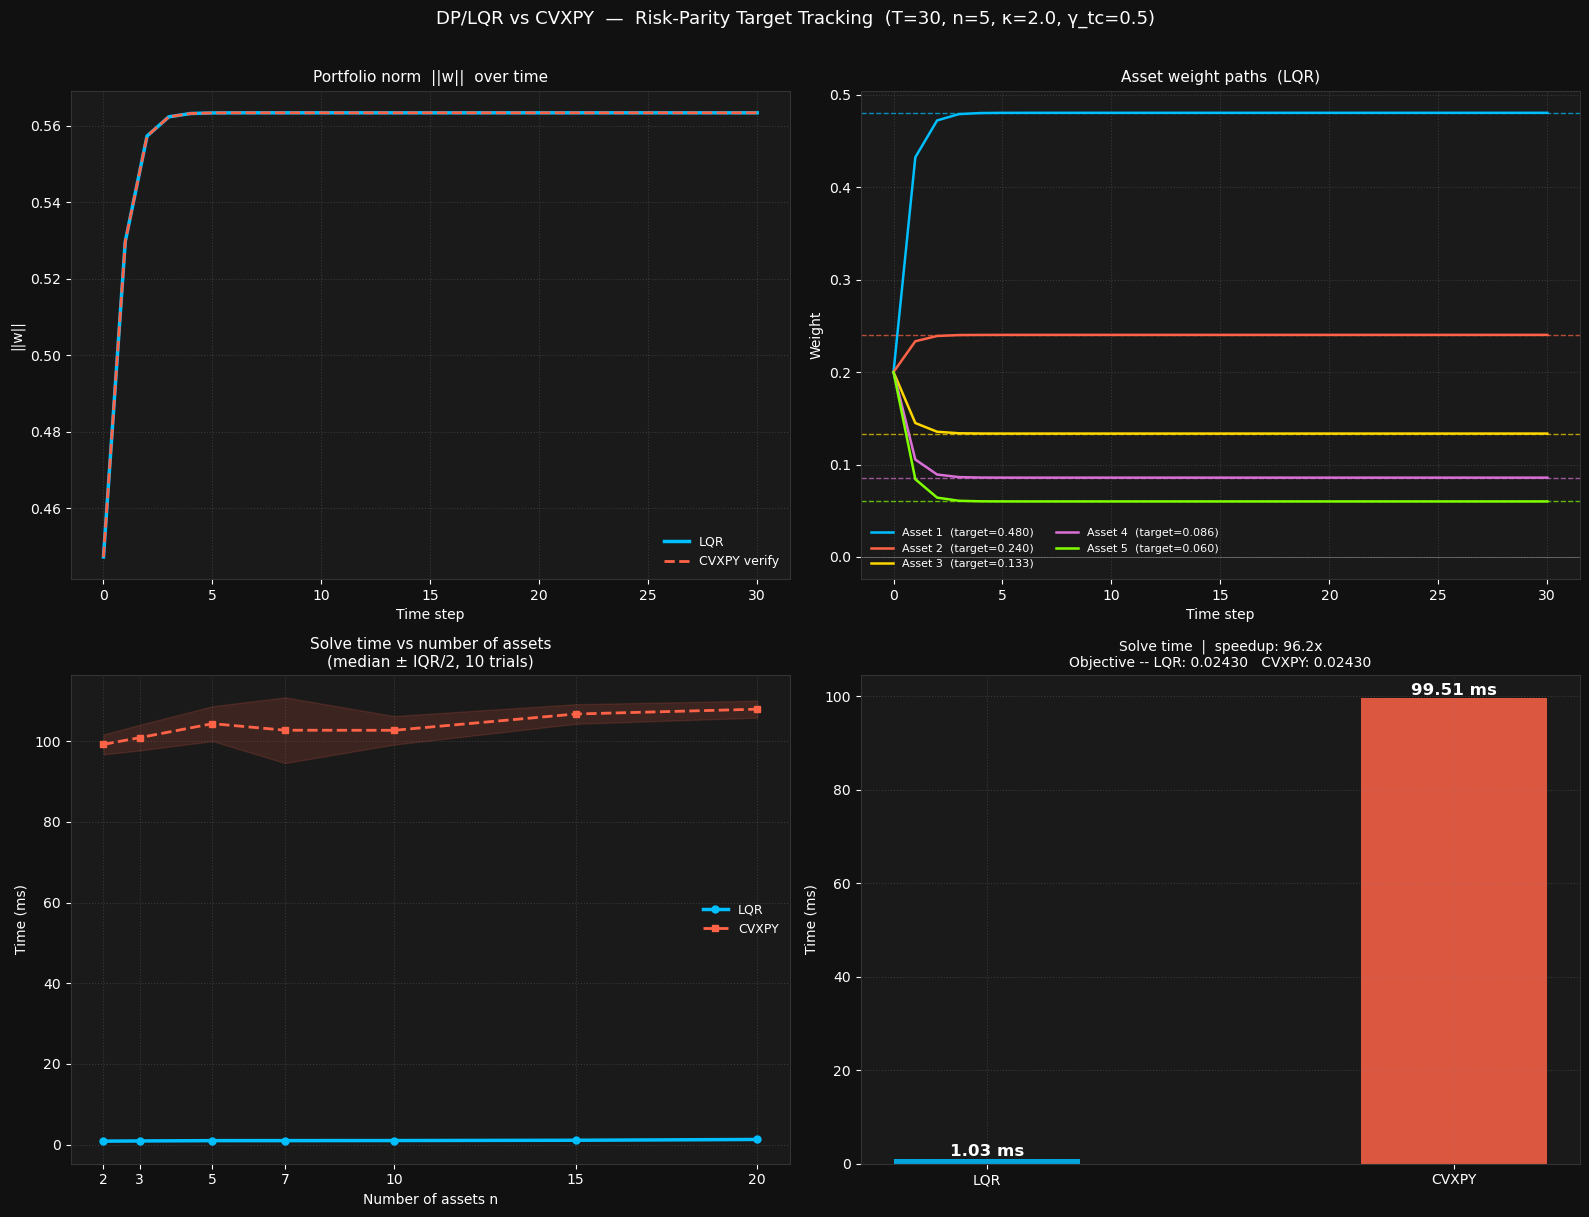

In [18]:
# ── D4  Plot ──────────────────────────────────────────────────────────
fig_rp = plot_multi_asset_results(
    W_lqr    = W_lqr_rp,
    W_cvx    = W_cvx_rp,
    time_lqr = time_lqr_rp,
    time_cvx = time_cvx_rp,
    speedup  = speedup_rp,
    obj_lqr  = obj_lqr_rp,
    obj_cvx  = obj_cvx_rp,
    w_given  = w_rp,          # target = risk-parity weights
    scaling  = rp_scaling,
    suptitle = (
        f"DP/LQR vs CVXPY  —  Risk-Parity Target Tracking  "
        f"(T={T_rp}, n={n_rp}, κ={kappa_rp}, γ_tc={gamma_tc_rp})"
    ),
    save_path='result/risk_parity_results.png',
)